# 1 CONFIG

In [1]:
import pandas as pd
import numpy as np
import datetime

import gspread
import gspread_dataframe as gd

from google.colab import data_table, auth
data_table.enable_dataframe_formatter()
auth.authenticate_user()

from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
downtime_path = '/content/drive/Shareddrives/**VEMP Supply Planning /Production Planning/Capacity assessment/Overall capacity/Cycle review/Template excel file/Downtime/Plant downtime.xls'

In [3]:
md_link = 'https://docs.google.com/spreadsheets/d/1rmmXS6owIJXdasK4AhoXzIVNy2p35UVeZ8n97yxh2ec/edit#gid=1834038647'
md_sheet = 'Master data'
md_range = 'B4:R'

In [4]:
# link last kanban được lấy từ ô A1 gs PKG plan send email sheetname link last kanban
kanban_link = gc.open_by_url('https://docs.google.com/spreadsheets/d/1BdLo51tIVjzrEKQOar24Csnq8dmqwKUriHWyEAFju4c/edit#gid=1127380590').worksheet('link last kanban').acell('A1').value
kanban_sheet = 'Copy of For Production'
kanban_range = 'E29:Q'

In [5]:
output_link = 'https://docs.google.com/spreadsheets/d/1SIDplAcsHSI6pgmBZFIKY2JehHwNklNo_q1i5fJSk80/edit#gid=1385140826'
output_sheet = 'Kết quả So sánh -New'
output_range = 'A1:J'

In [6]:
result_link = 'https://docs.google.com/spreadsheets/d/1rmmXS6owIJXdasK4AhoXzIVNy2p35UVeZ8n97yxh2ec/edit#gid=1101344338'
result_sheet = 'Cập nhật ca 1,2'
result_range = 'A1:G'

In [7]:
masterplan_link = 'https://docs.google.com/spreadsheets/d/1rmmXS6owIJXdasK4AhoXzIVNy2p35UVeZ8n97yxh2ec/edit#gid=1101344338'
masterplan_sheet = 'PKG BY SHIFT'
masterplan_range = 'G19:J354'
shift12_range = 'AB20:AC354'

In [8]:
# downtime today_datetime
# 'BUNDLELER'
# 0.06
# df_output['Date'].max()
# Shift '1'

# 2 DOWNTIME

In [9]:
# Read, clean
df_downtime = pd.read_csv(downtime_path, skiprows=4, usecols=[2,5,6,7,8], encoding='utf-16', delimiter='\t')
df_downtime = df_downtime.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df_downtime.columns = ['Machine', 'Start date', 'Start time', 'End date', 'End time']
df_downtime = df_downtime[df_downtime['Machine'].str.startswith('WP1FL') | df_downtime['Machine'].str.startswith('WP1HA')]
df_downtime['Machine'] = df_downtime['Machine'] = df_downtime['Machine'].str[3:9]
df_downtime['Machine'] = df_downtime['Machine'].replace({'FLW001': 'Flow wrap', 'FLW002': 'Flowrap 02'})
df_downtime.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28 entries, 593 to 620
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Machine     28 non-null     object
 1   Start date  28 non-null     object
 2   Start time  28 non-null     object
 3   End date    28 non-null     object
 4   End time    28 non-null     object
dtypes: object(5)
memory usage: 1.3+ KB


<ipython-input-9-d3365f799c23>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_downtime['Machine'] = df_downtime['Machine'] = df_downtime['Machine'].str[3:9]
<ipython-input-9-d3365f799c23>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_downtime['Machine'] = df_downtime['Machine'].replace({'FLW001': 'Flow wrap', 'FLW002': 'Flowrap 02'})


In [10]:
df_downtime.head()

,Machine,Start date,Start time,End date,End time
593,Flow wrap,06/14/2024,12:00:00,06/14/2024,14:00:00
594,Flowrap 02,06/14/2024,12:00:00,06/14/2024,14:00:00
595,HA0101,06/14/2024,12:00:00,06/14/2024,14:00:00
596,HA0101,06/27/2024,06:00:00,06/27/2024,12:00:00
597,HA0301,06/14/2024,12:00:00,06/14/2024,14:00:00


In [11]:
# Function to correct "24:00:00" time and adjust the date accordingly
def adjust_time_and_date(row):
    start_date = row['Start date']
    end_date = row['End date']
    start_time = row['Start time']
    end_time = row['End time']

    if start_time == '24:00:00':
        start_time = '00:00:00'
        start_date = (datetime.datetime.strptime(start_date, '%m/%d/%Y') + datetime.timedelta(days=1)).strftime('%m/%d/%Y')
    if end_time == '24:00:00':
        end_time = '00:00:00'
        end_date = (datetime.datetime.strptime(end_date, '%m/%d/%Y') + datetime.timedelta(days=1)).strftime('%m/%d/%Y')

    return start_date, start_time, end_date, end_time

# Apply the function to each row and update the dataframe
for index, row in df_downtime.iterrows():
    start_date, start_time, end_date, end_time = adjust_time_and_date(row)
    df_downtime.at[index, 'Start date'] = start_date
    df_downtime.at[index, 'Start time'] = start_time
    df_downtime.at[index, 'End date'] = end_date
    df_downtime.at[index, 'End time'] = end_time

# Now convert 'Start date', 'End date', 'Start time', and 'End time' to datetime
df_downtime['Start datetime'] = pd.to_datetime(df_downtime['Start date'] + ' ' + df_downtime['Start time'])
df_downtime['End datetime'] = pd.to_datetime(df_downtime['End date'] + ' ' + df_downtime['End time'])

# Define today's date for filtering
today_datetime = pd.to_datetime(datetime.datetime.now().date())

# Define shift start and end times
shift_1_start = today_datetime + datetime.timedelta(hours=6)
shift_1_end = today_datetime + datetime.timedelta(hours=14)
shift_2_start = today_datetime + datetime.timedelta(hours=14)
shift_2_end = today_datetime + datetime.timedelta(hours=22)

# Filter records for today's date
today_downtime = df_downtime[(df_downtime['Start datetime'].dt.date <= today_datetime.date()) &
                             (df_downtime['End datetime'].dt.date >= today_datetime.date())]

# Initialize a dictionary to store downtime for each machine
downtime_summary = {'Machine': [], 'Shift 1 Downtimes': [], 'Shift 2 Downtimes': []}

# Calculate downtime for each machine
for index, row in today_downtime.iterrows():
    machine = row['Machine']
    start = row['Start datetime']
    end = row['End datetime']

    # Calculate overlap with Shift 1
    shift_1_downtime = max(min(end, shift_1_end) - max(start, shift_1_start), datetime.timedelta(0)).total_seconds() / 3600
    # Calculate overlap with Shift 2
    shift_2_downtime = max(min(end, shift_2_end) - max(start, shift_2_start), datetime.timedelta(0)).total_seconds() / 3600

    if machine not in downtime_summary['Machine']:
        downtime_summary['Machine'].append(machine)
        downtime_summary['Shift 1 Downtimes'].append(shift_1_downtime)
        downtime_summary['Shift 2 Downtimes'].append(shift_2_downtime)
    else:
        machine_index = downtime_summary['Machine'].index(machine)
        downtime_summary['Shift 1 Downtimes'][machine_index] += shift_1_downtime
        downtime_summary['Shift 2 Downtimes'][machine_index] += shift_2_downtime

# Create a summary dataframe
df_today_downtime = pd.DataFrame(downtime_summary)
df_today_downtime.head()

,Machine,Shift 1 Downtimes,Shift 2 Downtimes
0,HA1301,8.0,0.0
1,HA1401,4.0,0.0


In [12]:
# Calculate capacity loss due to downtime
df_today_downtime['Shift 1 Off Capacity'] = df_today_downtime['Shift 1 Downtimes']/8
df_today_downtime['Shift 2 Off Capacity'] = df_today_downtime['Shift 2 Downtimes']/8
df_today_downtime = df_today_downtime.drop(columns=['Shift 1 Downtimes', 'Shift 2 Downtimes'])
df_today_downtime = df_today_downtime[
    (df_today_downtime['Shift 1 Off Capacity'] > 0) |
    (df_today_downtime['Shift 2 Off Capacity'] > 0)
]

## BẢNG DOWNTIME CA 1, 2 HÔM NAY

In [13]:
df_today_downtime

,Machine,Shift 1 Off Capacity,Shift 2 Off Capacity
0,HA1301,1.0,0.0
1,HA1401,0.5,0.0


In [14]:
df_today_downtime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Machine               2 non-null      object 
 1   Shift 1 Off Capacity  2 non-null      float64
 2   Shift 2 Off Capacity  2 non-null      float64
dtypes: float64(2), object(1)
memory usage: 176.0+ bytes


# 3 MASTER DATA

In [15]:
# Read, clean
df_md = pd.DataFrame.from_records(gc.open_by_url(md_link).worksheet(md_sheet).get(md_range))
df_md.columns = df_md.iloc[0,:]
df_md = df_md.iloc[1:,:]
df_md = df_md.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df_md.head()

,SKU,Bundle IM,Bristle,Machine,PKG type,LE qty (PMP),CC,MOQ,Auto CAP,BUNDLELER,Auto TRAY,Handle,Naked,Label machine,Output/shift,HC,SNP Status
1,1051840,K2+,S,FLOWWRAP,FLOWWRAP,140,72,140,CAP,,,,,,436.67,3.00,Active
2,1050468,PC_22,S,6pin,HA S6 1PK 42MM,75,72,150,,B,Auto tray,,,,835.00,8.00,Active
3,1050507,ZZAB_21,S,6pin,HA S6 1PK 42MM + C,75,72,150,,B,Auto tray,,,,783.00,9.00,Active
4,1050533,ZZAB_21,S,4pin,HA S4 3PK 70MM,24,288,48,,B,,,,label,380.00,10.00,Active
5,1051110,ECGC_17,S,4pin,HA S4 3PK 70MM,1,36,278,,,,,,label,"3,036.00",9.00,To be Discontinued


In [16]:
df_bundler = df_md[df_md['BUNDLELER'] == 'B'][['SKU', 'BUNDLELER']]

## BẢNG SKU BUNDLER

In [17]:
df_bundler

,SKU,BUNDLELER
2,1050468,B
3,1050507,B
4,1050533,B
7,1051118,B
8,1051826,B
...,...,...
251,61045756,B
258,61046381,B
259,61046397,B
260,61046611,B


In [18]:
df_bundler.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103 entries, 2 to 262
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   SKU        103 non-null    object
 1   BUNDLELER  103 non-null    object
dtypes: object(2)
memory usage: 2.4+ KB


# 4 KANBAN

In [19]:
# Read, clean
df_kanban = pd.DataFrame.from_records(gc.open_by_url(kanban_link).worksheet(kanban_sheet).get(kanban_range))
df_kanban.columns = df_kanban.iloc[0,:]
df_kanban = df_kanban.iloc[1:,:]
df_kanban.head()

,MACHINE,TB,PKG type,SKU,HC,CC,Output/shift,Shift 01,Shift 02,Shift 03,Shift 01,Shift 02,Shift 03
1,HA0101,DA_22_M,HA S6 1PK 42MM,61009149,4.5,120,501,501,501,496,501,501,496
2,HA0301,CC_21_M,HA S6 1PK 42MM,FVN50306,2.5,72,835,835,835,825,835,835,826
3,HA0301,CC_21_M,HA S6 1PK 42MM,61016705,2.5,72,835,None,None,None,None,None,None
4,HA0401,ZZAB_21_M,HA S6 1PK 42MM + C,61030077,6.5,12,4694,4694,4694,4500,764,None,None
5,HA0401,ZZCC_20_M,HA S6 1PK 42MM,61023052,4.5,72,835,,,,656,469,None


In [20]:
df_kanban = df_kanban.iloc[:, [0, 3, 6, 7, 8, 9, 10, 11, 12]]
df_kanban.columns = ['Machine', 'SKU', 'Output/shift', 'Shift1_yesterday', 'Shift2_yesterday', 'Shift3_yesterday', 'Shift1_today', 'Shift2_today', 'Shift3_today']
df_kanban = df_kanban.replace(',', '', regex=True)
df_kanban = df_kanban.applymap(lambda x: x.strip() if isinstance(x, str) else x)
for col in ['Output/shift', 'Shift1_yesterday', 'Shift2_yesterday', 'Shift3_yesterday', 'Shift1_today', 'Shift2_today', 'Shift3_today']:
    df_kanban[col] = pd.to_numeric(df_kanban[col], errors='coerce').fillna(0).astype(int)
df_kanban.head()

,Machine,SKU,Output/shift,Shift1_yesterday,Shift2_yesterday,Shift3_yesterday,Shift1_today,Shift2_today,Shift3_today
1,HA0101,61009149,501,501,501,496,501,501,496
2,HA0301,FVN50306,835,835,835,825,835,835,826
3,HA0301,61016705,835,0,0,0,0,0,0
4,HA0401,61030077,4694,4694,4694,4500,764,0,0
5,HA0401,61023052,835,0,0,0,656,469,0


In [21]:
df_off = df_kanban[['Machine', 'Shift1_today', 'Shift2_today']]
df_off = df_off.groupby('Machine').sum().reset_index()

# Step 1: Filter rows where either 'Shift1_today' or 'Shift2_today' is 0
df_off = df_off[(df_off['Shift1_today'] == 0) | (df_off['Shift2_today'] == 0)]

# Step 2: Melt the filtered DataFrame to create a long-form DataFrame
df_off = df_off.melt(id_vars=['Machine'], value_vars=['Shift1_today', 'Shift2_today'], var_name='Shift', value_name='Value')

# Step 3: Filter the melted DataFrame for rows where the value is 0
df_off = df_off[df_off['Value'] == 0]

# Drop the 'Value' column as it's not needed anymore
df_off = df_off.drop('Value', axis=1)

# Rename 'Shift' column to 'Off' and replace the shift names
df_off = df_off.rename(columns={'Shift': 'Off'})
df_off['Off'] = df_off['Off'].replace({'Shift1_today': 'Shift1', 'Shift2_today': 'Shift2'})

# Now df_machines_off contains the machines that are off in each shift
df_off = df_off.sort_values(by=['Machine', 'Off']).reset_index(drop=True)

## BẢNG MÁY TẮT

In [22]:
df_off

,Machine,Off
0,Flowrap 02,Shift1
1,Flowrap 02,Shift2
2,HA0601,Shift2
3,HA0801,Shift1
4,HA0801,Shift2
5,HA1101,Shift1
6,HA1301,Shift1
7,HA1301,Shift2
8,HA1401,Shift1
9,HA1501,Shift2


In [23]:
df_off.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Machine  10 non-null     object
 1   Off      10 non-null     object
dtypes: object(2)
memory usage: 288.0+ bytes


In [24]:
# Cộng nhu cầu theo kanban ngày hôm qua và hôm nay
df_kanban['Sum_plan'] = df_kanban['Shift1_yesterday'] + df_kanban['Shift2_yesterday'] + df_kanban['Shift3_yesterday'] + df_kanban['Shift1_today'] + df_kanban['Shift2_today'] + df_kanban['Shift3_today']
df_kanban = df_kanban[['Machine', 'SKU', 'Output/shift', 'Sum_plan']]
df_kanban = df_kanban[df_kanban['Sum_plan'] != 0]
df_kanban['Cum_sum_plan'] = df_kanban.groupby(['Machine', 'SKU'])['Sum_plan'].cumsum()

## BẢNG NHU CẦU HÔM QUA VÀ HÔM NAY

In [25]:
df_kanban

,Machine,SKU,Output/shift,Sum_plan,Cum_sum_plan
1,HA0101,61009149,501,2996,2996
2,HA0301,FVN50306,835,4991,4991
4,HA0401,61030077,4694,14652,14652
5,HA0401,61023052,835,1125,1125
6,HA0401,61041208,835,240,240
...,...,...,...,...,...
96,P1PR0004,1050460,900,252,252
97,P1PR0004,1050461,900,504,504
98,P1PR0004,61037835,900,756,756
99,P1PR0004,61037836,900,756,756


In [26]:
df_kanban.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66 entries, 1 to 100
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Machine       66 non-null     object
 1   SKU           66 non-null     object
 2   Output/shift  66 non-null     int64 
 3   Sum_plan      66 non-null     int64 
 4   Cum_sum_plan  66 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 3.1+ KB


# 5 OUTPUT

In [27]:
# Read, clean
df_output = pd.DataFrame.from_records(gc.open_by_url(output_link).worksheet(output_sheet).get(output_range))
df_output.columns = df_output.iloc[0,:]
df_output = df_output.iloc[1:,:]
df_output.head()

,Ngày,Nhóm,Ca,SKU,Máy,Opera,Lẻ giao ca,Lẻ ca trước để lại,SAP,So sánh
1,1/2/2024,A,1,1051416,PRPP0001,99,,0,99,0
2,1/2/2024,A,1,61005503,PRPP0001,14,,0,14,0
3,1/2/2024,A,1,VN00643A,PRPP0001,150,,0,150,0
4,1/2/2024,A,1,VN01040A,PRPP0001,69,,0,69,0
5,1/2/2024,A,1,1050459,PRPP0004,252,,0,252,0


In [28]:
# Lấy ra output ngày hôm qua, kể cả lẻ giao ca
df_output = df_output.iloc[:, [0, 2, 3, 4, 5, 7]]
df_output.columns = ['Date', 'Shift', 'SKU', 'Machine', 'Output', 'Lẻ ca trước để lại']
df_output = df_output.replace(',', '', regex=True)
df_output = df_output.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df_output['Date'] = pd.to_datetime(df_output['Date'], format='%m/%d/%Y')
df_output = df_output[df_output['Date']==df_output['Date'].max()]
df_output['Output'] = pd.to_numeric(df_output['Output'], errors='coerce').fillna(0).astype(int)
df_output['Lẻ ca trước để lại'] = pd.to_numeric(df_output['Lẻ ca trước để lại'], errors='coerce').fillna(0).astype(int)
df_output.head()

,Date,Shift,SKU,Machine,Output,Lẻ ca trước để lại
8971,2024-06-11,1,1051416,PRPP0001,278,0
8972,2024-06-11,1,1051825,PRPP0001,195,0
8973,2024-06-11,1,1050459,PRPP0004,126,0
8974,2024-06-11,1,61037835,PRPP0004,126,0
8975,2024-06-11,1,61037836,PRPP0004,252,0


## BỎ CỘNG LẺ GIAO CA Ở ĐÂY

In [29]:
# Update the 'Output' column where 'Shift' is '1' and 'Lẻ ca trước để lại' is greater than 0
#df_output.loc[(df_output['Shift'] == '1') & (df_output['Lẻ ca trước để lại'] > 0), 'Output'] += df_output['Lẻ ca trước để lại'] #
df_output = df_output.drop(columns=['Lẻ ca trước để lại'])
df_output.head()

,Date,Shift,SKU,Machine,Output
8971,2024-06-11,1,1051416,PRPP0001,278
8972,2024-06-11,1,1051825,PRPP0001,195
8973,2024-06-11,1,1050459,PRPP0004,126
8974,2024-06-11,1,61037835,PRPP0004,126
8975,2024-06-11,1,61037836,PRPP0004,252


In [30]:
# Đổi tên máy từ Opera sang giống Kanban
machine_mapping = {
    'SEHA0101': 'HA0101',
    'SEHA0301': 'HA0301',
    'SEHA0401': 'HA0401',
    'SEHA0501': 'HA0501',
    'SEHA0601': 'HA0601',
    'SEHA0801': 'HA0801',
    'SEHA0901': 'HA0901',
    'SEHA1001': 'HA1001',
    'SEHA1101': 'HA1101',
    'SEHA1201': 'HA1201',
    'SEHA1301': 'HA1301',
    'SEHM1401': 'HA1401',
    'SEHM1501': 'HA1501',
    'SEHM1601': 'HA1602',
    'SEHA1701': 'HA1701',
    'SEHA1801': 'HA1801',
    'SECLP03': 'Flow wrap',
    'SEFLW02': 'Flowrap 02',
    'PRPP0001': 'P1PR0001',
    'PRPP0004': 'P1PR0004'
}
df_output['Machine'] = df_output['Machine'].replace(machine_mapping)

In [31]:
df_output = df_output.groupby(['Machine', 'SKU'])['Output'].sum().reset_index()

## BẢNG OUTPUT NGÀY HÔM QUA

In [32]:
df_output

,Machine,SKU,Output
0,Flowrap 02,61034595,325
1,HA0101,61009149,1510
2,HA0301,FVN50306,2600
3,HA0401,61023052,26
4,HA0401,61030077,14652
5,HA0501,61030079,11052
6,HA0501,FVN50422,787
7,HA0601,61023721,1223
8,HA0601,61041209,722
9,HA0601,VN00154A,2688


In [33]:
df_output.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Machine  46 non-null     object
 1   SKU      46 non-null     object
 2   Output   46 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.2+ KB


# 6 MERGE KANBAN VÀ OUTPUT TÌM LƯỢNG THIẾU

In [34]:
df_kanban.head()

,Machine,SKU,Output/shift,Sum_plan,Cum_sum_plan
1,HA0101,61009149,501,2996,2996
2,HA0301,FVN50306,835,4991,4991
4,HA0401,61030077,4694,14652,14652
5,HA0401,61023052,835,1125,1125
6,HA0401,61041208,835,240,240


In [35]:
df = df_kanban.merge(df_output, how='left', on=['Machine','SKU'])
df['Output'] = df['Output'].fillna(0)
df['Shortage'] = df['Cum_sum_plan'] - df['Output']
df.head()

,Machine,SKU,Output/shift,Sum_plan,Cum_sum_plan,Output,Shortage
0,HA0101,61009149,501,2996,2996,1510.0,1486.0
1,HA0301,FVN50306,835,4991,4991,2600.0,2391.0
2,HA0401,61030077,4694,14652,14652,14652.0,0.0
3,HA0401,61023052,835,1125,1125,26.0,1099.0
4,HA0401,61041208,835,240,240,0.0,240.0


In [36]:
df = df[['Machine','SKU','Output/shift','Shortage']]
df.reset_index(drop=True, inplace=True)
df.head()

,Machine,SKU,Output/shift,Shortage
0,HA0101,61009149,501,1486.0
1,HA0301,FVN50306,835,2391.0
2,HA0401,61030077,4694,0.0
3,HA0401,61023052,835,1099.0
4,HA0401,61041208,835,240.0


In [37]:
df = df[df['Shortage']>0]
df.head()

,Machine,SKU,Output/shift,Shortage
0,HA0101,61009149,501,1486.0
1,HA0301,FVN50306,835,2391.0
3,HA0401,61023052,835,1099.0
4,HA0401,61041208,835,240.0
5,HA0401,61016707,501,520.0


In [38]:
# Tạo cột sequence lưu lại thứ tự chạy SKU (for reference)
df.reset_index(drop=True, inplace=True)
df['Sequence'] = 0

# Loop through the DataFrame and compare each row with the previous one
for i in range(len(df)):
    if i == 0 or df.loc[i, 'Machine'] != df.loc[i - 1, 'Machine']:
        df.loc[i, 'Sequence'] = 1
    else:
        df.loc[i, 'Sequence'] = df.loc[i - 1, 'Sequence'] + 1

df.head()

,Machine,SKU,Output/shift,Shortage,Sequence
0,HA0101,61009149,501,1486.0,1
1,HA0301,FVN50306,835,2391.0,1
2,HA0401,61023052,835,1099.0,1
3,HA0401,61041208,835,240.0,2
4,HA0401,61016707,501,520.0,3


In [39]:
# Define the standard and extra changeover penalties
changeover_penalty_standard = 0.02
changeover_penalty_include_bundler = 0.06

# Convert df_off to a dictionary for quick lookup, with Machine as keys and a set of Off shifts as values
off_dict = df_off.groupby('Machine')['Off'].apply(set).to_dict()

# Convert df_bundler to a list for quick lookup
bundler_skus = df_bundler['SKU'].tolist()

# Convert df_today_downtime to a dictionary for quick lookup
downtime_dict = df_today_downtime.set_index('Machine')[['Shift 1 Off Capacity', 'Shift 2 Off Capacity']].to_dict('index')

## FUNCTION XẾP PLAN

In [40]:
# Plan function
def schedule_machine(group):
    machine_name = group['Machine'].iloc[0]
    remaining_capacity_shift1 = 1
    remaining_capacity_shift2 = 1

    # Check if the machine has downtime capacity and adjust the remaining capacity
    if machine_name in downtime_dict:
        remaining_capacity_shift1 -= downtime_dict[machine_name]['Shift 1 Off Capacity']
        remaining_capacity_shift2 -= downtime_dict[machine_name]['Shift 2 Off Capacity']

    # Check if the machine is off in any shift and adjust the remaining capacity
    if machine_name in off_dict:
        if 'Shift1' in off_dict[machine_name]:
            remaining_capacity_shift1 = 0
        if 'Shift2' in off_dict[machine_name]:
            remaining_capacity_shift2 = 0

    # Iterate through the SKUs for each machine
    for index, row in group.iterrows():
        current_index = group.index.get_loc(index)
        current_sku = row['SKU']
        # Check if the current row is the last in the group
        if current_index < len(group) - 1:
            # If not, get the SKU of the next row
            next_sku = group.iloc[current_index + 1]['SKU']
        else:
            # If it is the last row, there is no next SKU
            next_sku = None

        # Calculate output for Shift 1
        output_shift1 = min(row['Shortage'], int(remaining_capacity_shift1 * row['Output/shift']))
        group.at[index, 'Shift1'] = output_shift1

        # Determine the changeover penalty based on the relationship between current and next SKUs
        if current_sku not in bundler_skus and next_sku in bundler_skus:
            changeover_penalty = changeover_penalty_include_bundler
        else:
            changeover_penalty = changeover_penalty_standard

        # Subtract the output from the remaining capacity for Shift 1
        remaining_capacity_shift1 -= output_shift1 / row['Output/shift']

        # Apply the changeover penalty for the next SKU if there is one
        remaining_capacity_shift1 -= changeover_penalty

        # Ensure the remaining capacity doesn't go negative for Shift 1
        remaining_capacity_shift1 = max(0, remaining_capacity_shift1)

        # Calculate remaining shortage after Shift 1
        remaining_shortage = row['Shortage'] - output_shift1

        # If there's still a shortage, calculate output for Shift 2
        if remaining_shortage > 0 and remaining_capacity_shift2 > 0:
            output_shift2 = min(remaining_shortage, int(remaining_capacity_shift2 * row['Output/shift']))
            group.at[index, 'Shift2'] = output_shift2

            # Subtract the output from the remaining capacity for Shift 2
            remaining_capacity_shift2 -= output_shift2 / row['Output/shift']

            # Apply the changeover penalty for the next SKU if there is one
            remaining_capacity_shift2 -= changeover_penalty

            # Ensure the remaining capacity doesn't go negative for Shift 2
            remaining_capacity_shift2 = max(0, remaining_capacity_shift2)

    return group

# Apply the scheduling function to each group
df = df.groupby('Machine', group_keys=False).apply(schedule_machine).reset_index(drop=True)

## BẢNG KẾT QUẢ CUỐI CÙNG

In [41]:
df = df[~((df['Shift1'] == 0) & (df['Shift2'].isnull()))]

In [42]:
df

,Machine,SKU,Output/shift,Shortage,Sequence,Shift1,Shift2
0,HA0101,61009149,501,1486.0,1,501.0,501.0
1,HA0301,FVN50306,835,2391.0,1,835.0,835.0
2,HA0401,61023052,835,1099.0,1,835.0,264.0
3,HA0401,61041208,835,240.0,2,0.0,240.0
4,HA0401,61016707,501,520.0,3,0.0,178.0
5,HA0501,61030079,5010,14071.0,1,5010.0,5010.0
6,HA0601,61023721,3440,6599.0,1,3440.0,NaN
8,HA0901,61034568,1660,485.0,1,485.0,NaN
9,HA0901,61034596,1660,1080.0,2,1080.0,NaN
10,HA0901,61003847,4980,6216.0,3,85.0,4980.0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 0 to 40
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Machine       35 non-null     object 
 1   SKU           35 non-null     object 
 2   Output/shift  35 non-null     int64  
 3   Shortage      35 non-null     float64
 4   Sequence      35 non-null     int64  
 5   Shift1        35 non-null     float64
 6   Shift2        24 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 2.2+ KB


# 7 PRINT RESULT

## IN KẾT QUẢ RA SHEET CẬP NHẬT CA 1,2

In [44]:
# Clear the existing data of result sheet
#gc.open_by_url(result_link).worksheet(result_sheet).clear() # xóa toàn bộ
gc.open_by_url(result_link).values_clear(f"{result_sheet}!{result_range}") # xóa 1 vùng

# Print the result to sheet
gd.set_with_dataframe(gc.open_by_url(result_link).worksheet(result_sheet),df)

## CẬP NHẬT VÀO MASTER PLAN

In [45]:
# Read PKG Master Plan
df_masterplan = pd.DataFrame.from_records(gc.open_by_url(masterplan_link).worksheet(masterplan_sheet).get(masterplan_range))
df_masterplan.columns = df_masterplan.iloc[0,:]
df_masterplan = df_masterplan.iloc[1:,:]
df_masterplan = df_masterplan.iloc[:, [0, 3]]
df_masterplan.columns = ['Machine', 'SKU']
df_masterplan = df_masterplan.replace(',', '', regex=True)
df_masterplan = df_masterplan.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df_masterplan

,Machine,SKU
1,HA0101,61009149
2,HA0101,None
3,HA0101,None
4,HA0101,None
5,HA0101,None
...,...,...
331,Flowrap 02,None
332,Flowrap 02,None
333,Flowrap 02,None
334,Flowrap 02,None


In [46]:
# Tạo thêm column để ghi nhận xem một SKU đang xuất hiện lần thứ máy trong máy để ghép số plan cho đúng dòng
df_masterplan['No of Occurrence'] = df_masterplan.groupby(['Machine', 'SKU']).cumcount() + 1
df_masterplan.head()

,Machine,SKU,No of Occurrence
1,HA0101,61009149,1.0
2,HA0101,None,NaN
3,HA0101,None,NaN
4,HA0101,None,NaN
5,HA0101,None,NaN


In [47]:
df_masterplan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 1 to 335
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Machine           335 non-null    object 
 1   SKU               77 non-null     object 
 2   No of Occurrence  77 non-null     float64
dtypes: float64(1), object(2)
memory usage: 8.0+ KB


In [48]:
# Tạo thêm column để ghi nhận xem một SKU đang xuất hiện lần thứ máy trong máy để ghép số plan cho đúng dòng
df['No of Occurrence'] = df.groupby(['Machine', 'SKU']).cumcount() + 1
df.head()

,Machine,SKU,Output/shift,Shortage,Sequence,Shift1,Shift2,No of Occurrence
0,HA0101,61009149,501,1486.0,1,501.0,501.0,1
1,HA0301,FVN50306,835,2391.0,1,835.0,835.0,1
2,HA0401,61023052,835,1099.0,1,835.0,264.0,1
3,HA0401,61041208,835,240.0,2,0.0,240.0,1
4,HA0401,61016707,501,520.0,3,0.0,178.0,1


In [49]:
df_masterplan = df_masterplan.merge(df[['Machine','SKU','Shift1','Shift2','No of Occurrence']], how='left', on=['Machine','SKU','No of Occurrence'])
df_masterplan

,Machine,SKU,No of Occurrence,Shift1,Shift2
0,HA0101,61009149,1.0,501.0,501.0
1,HA0101,None,NaN,NaN,NaN
2,HA0101,None,NaN,NaN,NaN
3,HA0101,None,NaN,NaN,NaN
4,HA0101,None,NaN,NaN,NaN
...,...,...,...,...,...
330,Flowrap 02,None,NaN,NaN,NaN
331,Flowrap 02,None,NaN,NaN,NaN
332,Flowrap 02,None,NaN,NaN,NaN
333,Flowrap 02,None,NaN,NaN,NaN


In [50]:
# After merged, no need column No of Occurrence
df_masterplan.drop('No of Occurrence', axis=1, inplace=True)
df_masterplan.head()

,Machine,SKU,Shift1,Shift2
0,HA0101,61009149,501.0,501.0
1,HA0101,None,NaN,NaN
2,HA0101,None,NaN,NaN
3,HA0101,None,NaN,NaN
4,HA0101,None,NaN,NaN


In [51]:
# Cập nhật ca 1, 2 vào Master Plan
worksheet = gc.open_by_url(masterplan_link ).worksheet(masterplan_sheet)
df_shift12 = df_masterplan[['Shift1', 'Shift2']]
df_shift12 = df_shift12.fillna("")
df_shift12 = df_shift12.replace(0, "")
# Get the cell range in the worksheet where you want to set the values
cell_range = worksheet.range(shift12_range)

# Flatten the DataFrame values into a list
values = df_shift12.values.flatten()

# Assign the values to the cells in the range
for i, cell in enumerate(cell_range):
    if i < len(values):  # Make sure we don't go past the DataFrame's number of values
        cell.value = values[i]
    else:
        cell.value = ""  # Assign empty string to the remaining cells if any

# Update the cells in the worksheet
worksheet.update_cells(cell_range)

{'spreadsheetId': '1rmmXS6owIJXdasK4AhoXzIVNy2p35UVeZ8n97yxh2ec',
 'updatedRange': "'PKG BY SHIFT'!AB20:AC354",
 'updatedRows': 335,
 'updatedColumns': 2,
 'updatedCells': 670}

In [52]:
print('DONE')

DONE


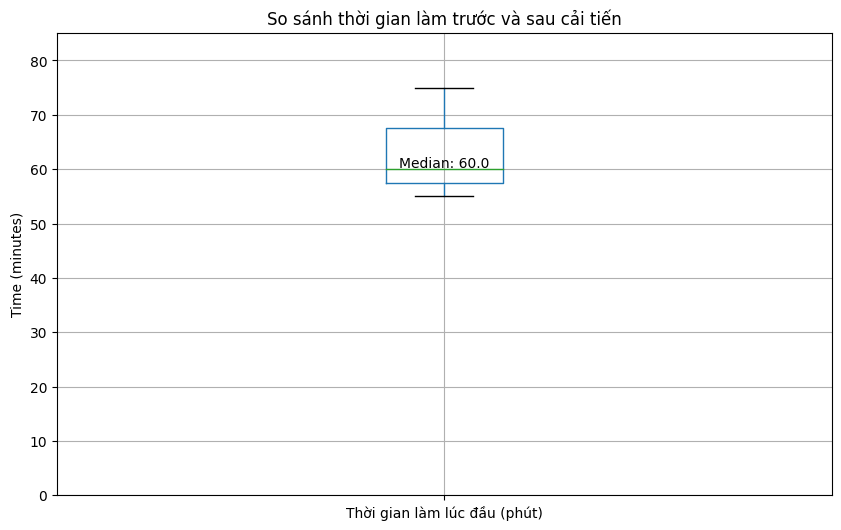

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame with your data
data = {
    'Thời gian làm lúc đầu (phút)': [75, 70, 60, 60, 55, 55, 65],
    'Thời gian sau cải tiến (phút)': [20, 15, 10, 10, 10, 25, 15]
}

df = pd.DataFrame(data)

# Create a box plot for 'Thời gian làm lúc đầu (phút)' only
plt.figure(figsize=(10, 6))  # Set the figure size
boxplot = df.boxplot(column=['Thời gian làm lúc đầu (phút)'])

# Set the title and labels
plt.title('So sánh thời gian làm trước và sau cải tiến')
plt.ylabel('Time (minutes)')
plt.grid(True)

# Set the y-axis to start at 0
plt.ylim(0, df['Thời gian làm lúc đầu (phút)'].max() + 10)  # Adjust the max value as needed

# Annotate the median value on the plot
median = df['Thời gian làm lúc đầu (phút)'].median()
plt.text(1, median + 1, f'Median: {median}', ha='center', va='center')

# Show the plot
plt.show()

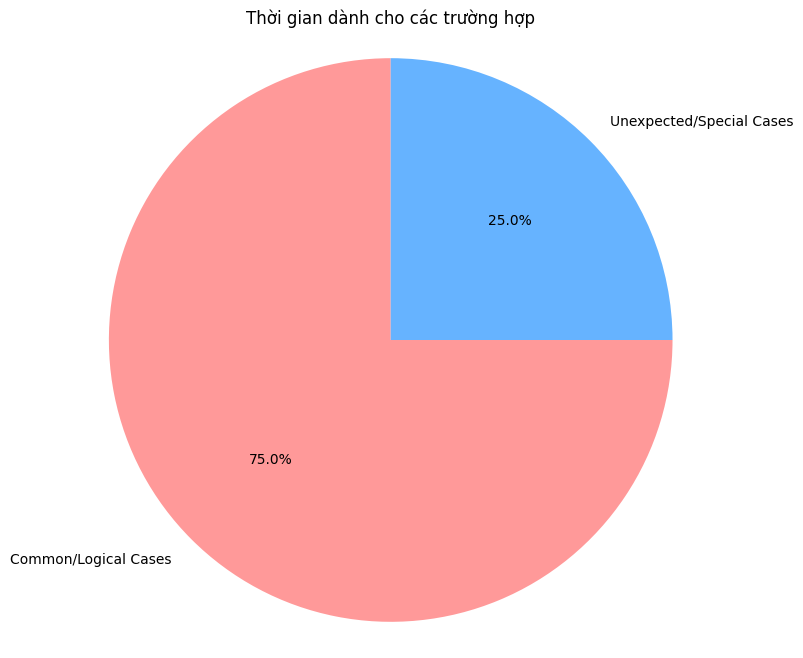

In [54]:
import matplotlib.pyplot as plt

# Define the data for the pie chart
labels = ['Common/Logical Cases', 'Unexpected/Special Cases']
sizes = [45, 15]  # The time spent on each type of case
colors = ['#ff9999','#66b3ff']  # Optional: You can specify colors for each slice

# Create the pie chart
plt.figure(figsize=(8, 8))  # Set the figure size
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)

# Set the title
plt.title('Thời gian dành cho các trường hợp')

# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis('equal')

# Show the plot
plt.show()

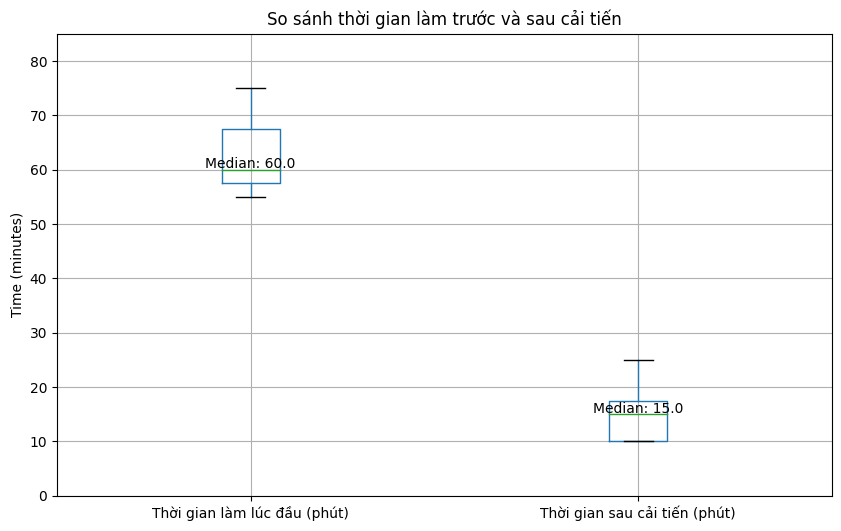

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame with your data
data = {
    'Thời gian làm lúc đầu (phút)': [75, 70, 60, 60, 55, 55, 65],
    'Thời gian sau cải tiến (phút)': [20, 15, 10, 10, 10, 25, 15]
}

df = pd.DataFrame(data)

# Create a box plot
plt.figure(figsize=(10, 6))  # Set the figure size
boxplot = df.boxplot(column=['Thời gian làm lúc đầu (phút)', 'Thời gian sau cải tiến (phút)'])

# Set the title and labels
plt.title('So sánh thời gian làm trước và sau cải tiến')
plt.ylabel('Time (minutes)')
plt.grid(True)

# Set the y-axis to start at 0
plt.ylim(0, df.max().max() + 10)  # Adjust the max value as needed

# Annotate the median values on the plot
medians = [df[col].median() for col in df.columns]
for i, median in enumerate(medians):
    plt.text(i + 1, median + 1, f'Median: {median}', ha='center', va='center')

# Show the plot
plt.show()

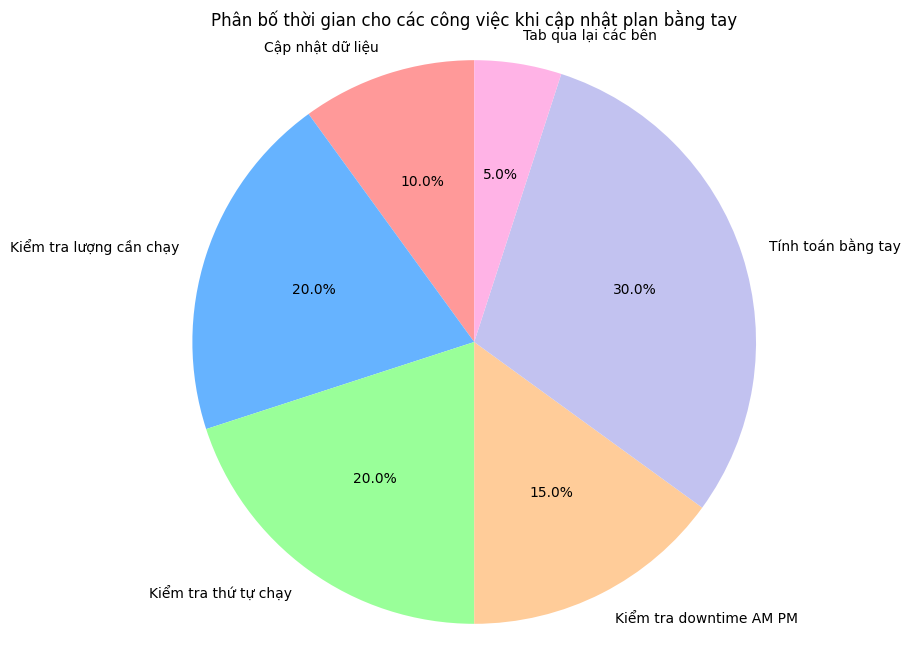

In [56]:
import matplotlib.pyplot as plt

# Define the data for the pie chart
labels = ['Cập nhật dữ liệu', 'Kiểm tra lượng cần chạy', 'Kiểm tra thứ tự chạy', 'Kiểm tra downtime AM PM', 'Tính toán bằng tay', 'Tab qua lại các bên']
sizes = [10, 20, 20, 15, 30, 5]  # The time spent on each task
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']  # Optional: You can specify colors for each slice

# Create the pie chart
plt.figure(figsize=(8, 8))  # Set the figure size
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)

# Set the title
plt.title('Phân bố thời gian cho các công việc khi cập nhật plan bằng tay')

# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis('equal')

# Show the plot
plt.show()